Loading in the Dataset

In [2]:
# Import Pandas Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import dataset as variable df
df = pd.read_csv('/content/fraud.csv')

In [3]:
# Lets peak at the data
df.head()

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
0,161.363691,3.0,0.0,2.0,18.000000,2.0,26.539742,1.0,48.403937,0.0,0.0,3.718296,0
1,116.202851,1.0,1.0,4.0,26.285818,2.0,50.714402,NaN,76.144979,0.0,0.0,4.951272,0
2,1.000000,2.0,0.0,5.0,18.000000,NaN,9.467935,0.0,67.600316,0.0,0.0,4.556043,0
3,48.780618,2.0,0.0,3.0,44.471190,NaN,41.077068,0.0,94.825526,0.0,0.0,6.918437,0
4,NaN,3.0,0.0,4.0,38.733609,8.0,NaN,2.0,100.000000,0.0,1.0,5.535335,1


Looking at the data

In [4]:
# Get basic DataFrame information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_amount    6440 non-null   float64
 1   hour_of_day           6650 non-null   float64
 2   is_weekend            6860 non-null   float64
 3   num_items             6790 non-null   float64
 4   customer_age          6160 non-null   float64
 5   prev_transactions     6510 non-null   float64
 6   distance_from_home    6300 non-null   float64
 7   device_type           6720 non-null   float64
 8   network_quality       6370 non-null   float64
 9   is_first_transaction  6790 non-null   float64
 10  store_type            6860 non-null   float64
 11  velocity_score        5950 non-null   float64
 12  is_fraud              7000 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 711.1 KB


In [5]:
# Lets look at the amount of rows and columns
df.shape

(7000, 13)

Null Values


In [6]:
# finding how many columns contain null values
null_columns = df.isnull().any()
num_null_columns = null_columns.sum()
print(num_null_columns)

12


In [7]:
# count how many nulls are in each column
null_counts = df.isnull().sum()
print(null_counts)

transaction_amount       560
hour_of_day              350
is_weekend               140
num_items                210
customer_age             840
prev_transactions        490
distance_from_home       700
device_type              280
network_quality          630
is_first_transaction     210
store_type               140
velocity_score          1050
is_fraud                   0
dtype: int64


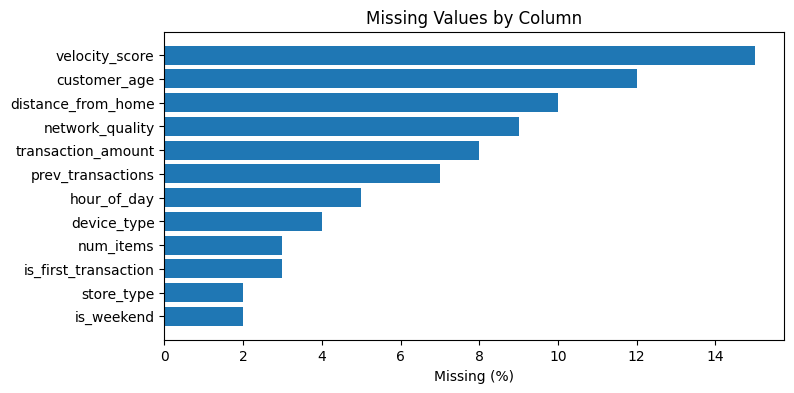

In [8]:
# Calculate missing value percentages
missing = df.isnull().mean() * 100

# Keep only columns with missing values
missing = missing[missing > 0].sort_values()

# Plot
plt.figure(figsize=(8,4))

plt.barh(missing.index, missing.values)

plt.xlabel('Missing (%)')
plt.title('Missing Values by Column')

plt.show()

In [9]:
# Import KNN Imputer
from sklearn.impute import KNNImputer

# Replacing null values

# Median-based average for continuous variables
df['transaction_amount'].fillna(df['transaction_amount'].median(), inplace=True)
df['num_items'].fillna(df['num_items'].median(), inplace=True)
df['prev_transactions'].fillna(df['prev_transactions'].median(), inplace=True)
df['network_quality'].fillna(df['network_quality'].median(), inplace=True)

# Mode-based for discrete variables
df['hour_of_day'].fillna(df['hour_of_day'].mode()[0], inplace=True)
df['device_type'].fillna(df['device_type'].mode()[0], inplace=True)
df['store_type'].fillna(df['store_type'].mode()[0], inplace=True)

# Binary variables - fill NA with 0
df['is_weekend'].fillna(0, inplace=True)
df['is_first_transaction'].fillna(0, inplace=True)

# Group-based imputation for customer age based on store type
df['customer_age'] = df.groupby('store_type')['customer_age'].transform(
    lambda x: x.fillna(x.median())
)

# Group-based imputation for distance from home
df['distance_from_home'] = (
    df.groupby(['device_type', 'store_type'])['distance_from_home']
    .transform(lambda x: x.fillna(x.median()))
)

# KNN imputation for velocity score
imputer = KNNImputer(n_neighbors=5)

df[['velocity_score']] = imputer.fit_transform(
    df[['velocity_score']]
)

/tmp/ipykernel_5280/353286865.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['transaction_amount'].fillna(df['transaction_amount'].median(), inplace=True)
/tmp/ipykernel_5280/353286865.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [10]:
# lets look at the nulls now
null_counts = df.isnull().sum()
print(null_counts)

transaction_amount      0
hour_of_day             0
is_weekend              0
num_items               0
customer_age            0
prev_transactions       0
distance_from_home      0
device_type             0
network_quality         0
is_first_transaction    0
store_type              0
velocity_score          0
is_fraud                0
dtype: int64


Discriptive Statistics


In [11]:
df.describe()


,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.00000,7000.000000,7000.000000
mean,99.972052,2.190857,0.106429,2.978000,36.096662,4.355571,24.086815,0.670857,74.203784,0.093000,0.28100,5.007450,0.103000
std,47.086370,0.662188,0.308407,1.686563,12.464668,4.722322,23.175483,0.773328,17.177962,0.290453,0.44952,1.850923,0.303981
min,1.000000,1.000000,0.000000,0.000000,18.000000,0.000000,0.004282,0.000000,0.477174,0.000000,0.00000,-1.853966,0.000000
25%,69.190103,2.000000,0.000000,2.000000,26.873184,1.000000,8.382719,0.000000,62.961134,0.000000,0.00000,3.940951,0.000000
50%,99.482201,2.000000,0.000000,3.000000,35.235238,3.000000,17.735292,0.000000,75.306346,0.000000,0.00000,5.007450,0.000000
75%,129.347921,3.000000,0.000000,4.000000,43.826736,6.000000,32.321667,1.000000,86.896943,0.000000,1.00000,6.078388,0.000000
max,296.311885,3.000000,1.000000,13.000000,80.000000,40.000000,224.699757,2.000000,100.000000,1.000000,1.00000,12.659564,1.000000


Looking at the distribition


/tmp/ipykernel_5280/1132493587.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, palette='cool')


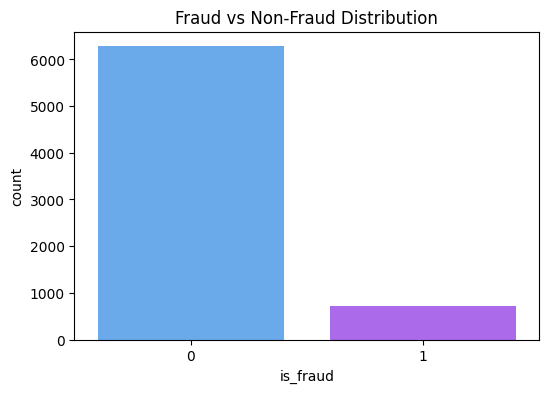

In [12]:
# Lets look at the distribution of fraud to not fraud
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df, palette='cool')
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()


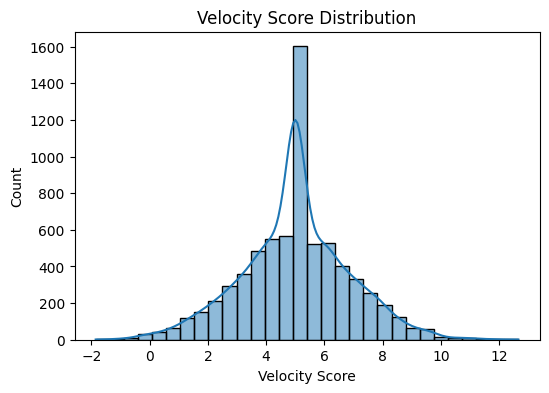

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.histplot(df['velocity_score'], bins=30, kde=True)

plt.title("Velocity Score Distribution")
plt.xlabel("Velocity Score")
plt.ylabel("Count")

plt.show()

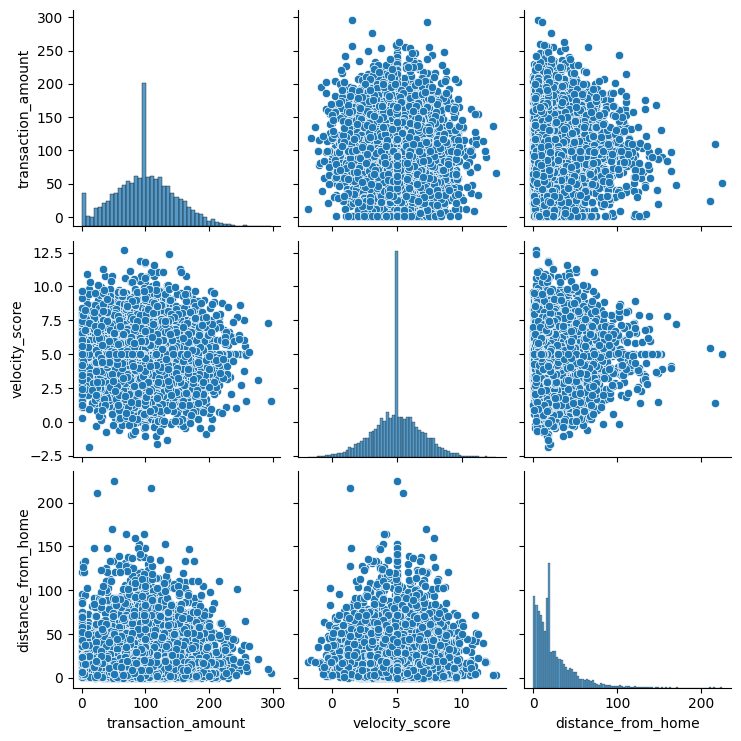

In [18]:
# scatter matrix of the relationships between transaction amount, velosity score, distance from home.
sns.pairplot(df, vars=['transaction_amount', 'velocity_score', 'distance_from_home'])
plt.show()

In [20]:
df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)

,is_fraud
is_fraud,1.000000
distance_from_home,0.046890
is_first_transaction,0.012860
transaction_amount,0.011939
store_type,0.011919
prev_transactions,0.004841
is_weekend,0.000404
network_quality,-0.000947
customer_age,-0.010525
hour_of_day,-0.013918


In [14]:
y = df['is_fraud']
X = df.drop('is_fraud', axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate
classifier = RandomForestClassifier(n_estimators=100, criterion = 'entropy', random_state=42)

# Fit
classifier.fit(X_train, y_train)

# Predict
y_pred = classifier.predict(X_test)

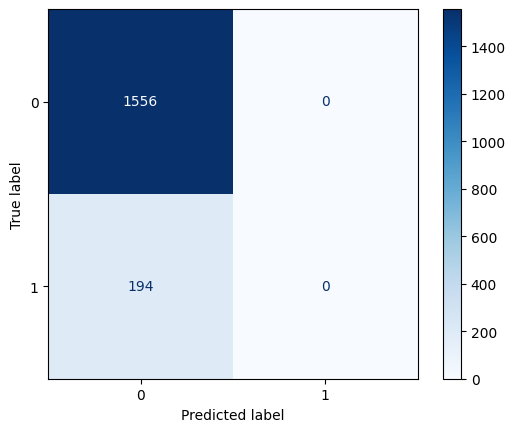

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot(cmap = plt.cm.Blues)
plt.show()

In [17]:
from sklearn.metrics import accuracy_score

print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")

Accuracy Score: 0.8891428571428571
